## Рубежный контроль № 1
### Вариант 21 | Группа ИУ5-61Б | Савельева Дарья
### Задача 3 | Набор данных: Graduate Admissions

* StandardScaler — приводит данные к нулевому среднему и единичной дисперсии, чтобы уравнять влияние признаков.
* Label Encoding — заменяет текстовые категории на целые числа, компактен, но привносит искусственный порядок.
* One-Hot Encoding — создаёт бинарные столбцы для каждой категории, убирая порядок, но увеличивая размерность.


Первые 5 строк датасета:
   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
0           1        337          118                  4  4.5  4.5  9.65   
1           2        324          107                  4  4.0  4.5  8.87   
2           3        316          104                  3  3.0  3.5  8.00   
3           4        322          110                  3  3.5  2.5  8.67   
4           5        314          103                  2  2.0  3.0  8.21   

   Research  Chance of Admit  
0         1                1  
1         1                1  
2         1                0  
3         1                1  
4         0                0  

Распределение категорий:
Univ_Category
High      134
Medium    133
Low       133
Name: count, dtype: int64

Пропуски до обработки:
GRE Score        10
Univ_Category     5
dtype: int64
Пропуски в GRE Score заполнены медианой: 317.0
Пропуски в Univ_Category заполнены модой: Low

Пропуски после обработки:
GRE Score        0
Univ_Cat

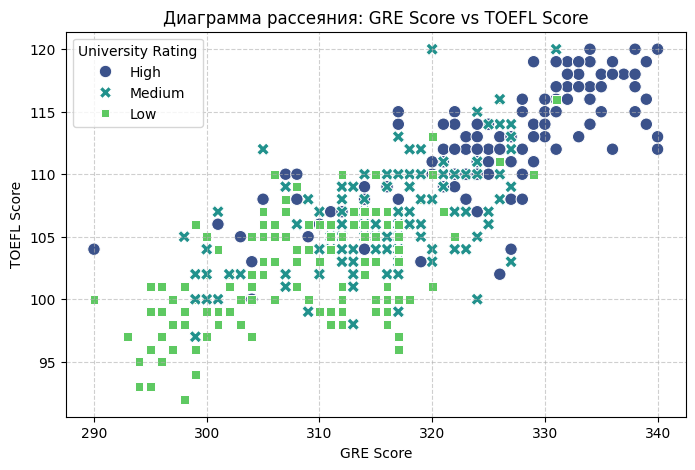

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import OneHotEncoder

url = "https://raw.githubusercontent.com/tkseneee/Dataset/master/Admission_Predict.csv"
df = pd.read_csv(url)
print("Первые 5 строк датасета:")
print(df.head())

def rating_to_category(rating):
    if rating <= 2:
        return 'Low'
    elif rating == 3:
        return 'Medium'
    else:
        return 'High'

df['Univ_Category'] = df['University Rating'].apply(rating_to_category)
print("\nРаспределение категорий:")
print(df['Univ_Category'].value_counts())

np.random.seed(42)

gre_missing_idx = np.random.choice(df.index, size=10, replace=False)
df.loc[gre_missing_idx, 'GRE Score'] = np.nan

cat_missing_idx = np.random.choice(df.index, size=5, replace=False)
df.loc[cat_missing_idx, 'Univ_Category'] = np.nan

print("\nПропуски до обработки:")
print(df[['GRE Score', 'Univ_Category']].isnull().sum())

median_gre = df['GRE Score'].median()
df['GRE Score'] = df['GRE Score'].fillna(median_gre)
print(f"Пропуски в GRE Score заполнены медианой: {median_gre}")

mode_cat = df['Univ_Category'].mode()[0]
df['Univ_Category'] = df['Univ_Category'].fillna(mode_cat)
print(f"Пропуски в Univ_Category заполнены модой: {mode_cat}")

print("\nПропуски после обработки:")
print(df[['GRE Score', 'Univ_Category']].isnull().sum())

scaler = StandardScaler()
df['TOEFL_Score_scaled'] = scaler.fit_transform(df[['TOEFL Score']])
print("\nМасштабирование TOEFL Score (первые 5 строк):")
print(df[['TOEFL Score', 'TOEFL_Score_scaled']].head())

label_enc = LabelEncoder()
df['Univ_Category_Label'] = label_enc.fit_transform(df['Univ_Category'])
print("\nLabel Encoding (первые 5 строк):")
print(df[['Univ_Category', 'Univ_Category_Label']].head())

onehot_enc = OneHotEncoder(sparse_output=False)
cat_encoded = onehot_enc.fit_transform(df[['Univ_Category']])
cat_ohe_df = pd.DataFrame(cat_encoded,
                          columns=onehot_enc.categories_[0],
                          index=df.index)
df = pd.concat([df, cat_ohe_df], axis=1)
print("\nOne-Hot Encoding (первые 5 строк):")
print(df[['Univ_Category', 'High', 'Low', 'Medium']].head())

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='GRE Score', y='TOEFL Score',
                hue='Univ_Category', style='Univ_Category',
                palette='viridis', s=80)
plt.title('Диаграмма рассеяния: GRE Score vs TOEFL Score')
plt.xlabel('GRE Score')
plt.ylabel('TOEFL Score')
plt.legend(title='University Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()